<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

Tue Aug  5 04:35:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Hyperparam Zone
import os

RANDOM_SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [ ]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)
print(torch.__file__)  # should point to site-packages, not your project dir
print(torch.optim.Adam)


# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

2.6.0+cu124
/usr/local/lib/python3.11/dist-packages/torch/__init__.py
<class 'torch.optim.adam.Adam'>
cpu


## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

1. Making your model more complex or flexible so that it can better capture the patterns in the data
2. Train your model for longer
3. Reduce noise in the data (as it says in [Simplilearn](https://www.simplilearn.com/tutorials/machine-learning-tutorial/overfitting-and-underfitting#reasons_for_underfitting))
4. Increase the number of features in the dataset (again, from the same Simplilearn article)


## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [ ]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

data_path = Path("data")
image_path = data_path / "pizza_steak_sushi" #I am going to load it into this one, just as in the walkthrough

def create_path(path):
  if path.is_dir():
    print(f"'{path}' directory already exists. Skipping download")
  else:
    print(f"'{path}' directory does not exist yet. Creating...")
    path.mkdir(parents=True, exist_ok=True)
    print(f"'{path}' path created.")

In [ ]:
type(data_path)

pathlib.PosixPath

In [ ]:
def download_data(path, file_name_w_extension, url, unzip_file=False):
  with open(path / file_name_w_extension, "wb") as f:
    req = requests.get(url)
    print(f"Downloading '{file_name_w_extension}' from the specified URL")
    f.write(req.content)
  if unzip_file:
    unzip_data(path, file_name_w_extension)

def unzip_data(path, file_name_w_extension):
  with zipfile.ZipFile( path / file_name_w_extension, "r") as zip_ref:
    print("Unzipping the data")
    zip_ref.extractall(path)

In [ ]:
def create_data_path_and_download_zip(folder_name, file_name_w_extension, url):
  data_path = Path("data")
  user_specific_path = data_path / folder_name
  create_path(
      path = user_specific_path
  )
  download_data(
      path = user_specific_path,
      file_name_w_extension = file_name_w_extension,
      url = url,
      unzip_file = True
  )
  return user_specific_path


In [ ]:
image_path = create_data_path_and_download_zip(
    folder_name="pizza_steak_sushi",
    file_name_w_extension="pizza_steak_sushi.zip",
    url="https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip"
)

'data/pizza_steak_sushi' directory does not exist yet. Creating...
'data/pizza_steak_sushi' path created.
Unzipping the data


In [ ]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [ ]:
walk_through_dir(image_path)

There are 2 directories and 1 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.


In [ ]:
# Setup train and testing paths
def set_train_test_dir(image_path):
  """Receives an image path and creates the subpaths for the Train and Test directories"""
  train_dir = image_path / "train"
  test_dir = image_path / "test"
  return train_dir, test_dir

In [ ]:
train_dir, test_dir = set_train_test_dir(image_path)
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
def create_data_path_and_download_zip_2(folder_name, file_name_w_extension, url):
  """Receives where to store your data, what the name of the file is, and where to get it from.

    Returns:
      (image_path, train_dir, test_dir) : A tuple with all the different image paths relevant
  """
  data_path = Path("data")
  user_specific_path = data_path / folder_name
  print(f"The path that will be created: {user_specific_path}")
  create_path(
      path=user_specific_path
  )
  download_data(
      path=user_specific_path,
      file_name_w_extension=file_name_w_extension,
      url=url,
      unzip_file=True
  )
  train_dir, test_dir = set_train_test_dir(user_specific_path)
  return (user_specific_path, train_dir, test_dir)

In [ ]:
image_path, train_dir, test_dir = create_data_path_and_download_zip_2(
    folder_name = "pizza_steak_sushi",
    file_name_w_extension = "pizza_steak_sushi.zip",
    url="https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip"
)

The path that will be created: data/pizza_steak_sushi
'data/pizza_steak_sushi' directory already exists. Skipping download
Unzipping the data


In [ ]:
# Visualize an image
from PIL import Image
import random

random.seed(RANDOM_SEED)

def get_all_image_paths(image_path):
  return list(image_path.glob("*/*/*.jpg"))

image_path_list = get_all_image_paths(image_path)
len(image_path_list), image_path_list[:5]

(300,
 [PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/309892.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg')])

In [ ]:
def get_random_image(image_path):
  image_path_list = get_all_image_paths(image_path)
  img_path = random.choice(image_path_list)
  image_class = img_path.parent.stem

  img = Image.open(img_path)
  print(f"Random image path: {img_path}")
  print(f"Class: {image_class}")
  print(f"Height: {img.height} | Width: {img.width}")
  return img

Random image path: data/pizza_steak_sushi/test/steak/966174.jpg
Class: steak
Height: 512 | Width: 512


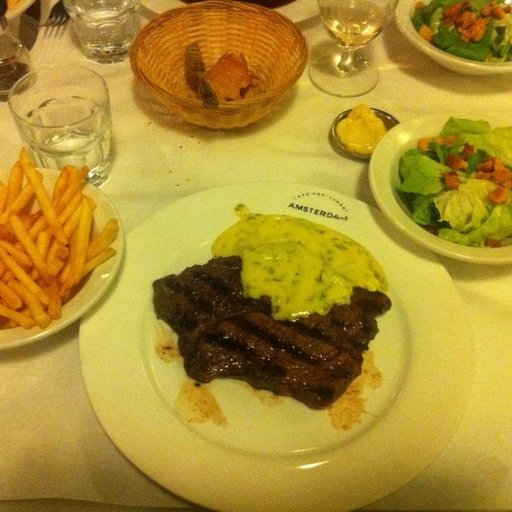

In [ ]:
img = get_random_image(image_path)
img

In [ ]:
# Do the image visualization with matplotlib
import matplotlib.pyplot as plt

def display_random_image_matplot(image_path):
  image_path_list = list(image_path.glob("*/*/*.jpg"))
  img_path = random.choice(image_path_list)
  image_class = img_path.parent.stem

  img = Image.open(img_path)
  plt.title(image_class)
  plt.axis(False)
  plt.imshow(img)

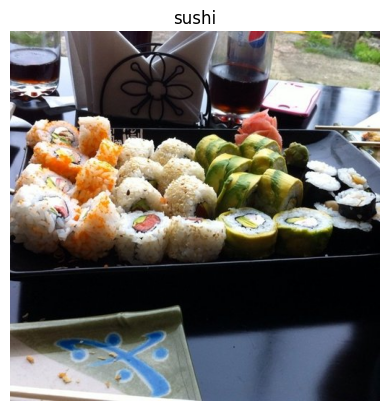

In [ ]:
display_random_image_matplot(image_path)

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [ ]:
# 3.1 Transforming data with torchvision.transforms
from torchvision import transforms

train_transform_tvgg = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

test_transform_tvgg = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

img = get_random_image(image_path)
transformed_img = train_transform_tvgg(img)

Random image path: data/pizza_steak_sushi/test/sushi/1245193.jpg
Class: sushi
Height: 295 | Width: 512


In [ ]:
# Write a function to plot transformed images
def display_transformation(image_path, transform):
  img = Image.open(image_path)
  transformed_img = transform(img)
  fig, ax = plt.subplots(nrows=1, ncols=2)
  ax[0].imshow(img)
  ax[0].axis(False)
  ax[0].set_title(f"OG {img.size}")

  ax[1].imshow(transformed_img.permute(1, 2, 0))
  ax[1].axis(False)
  ax[1].set_title(f"Tr {transformed_img.shape}")

  fig.suptitle(f"Class: {image_path.parent}", fontsize=14)
  return transformed_img

In [ ]:
def display_random_img_transformation(image_path, transform, n: int = 3):
  for i in range(0, n):
    random_img_path = random.choice(list(image_path.glob("*/*/*.jpg")))
    display_transformation(random_img_path, transform)

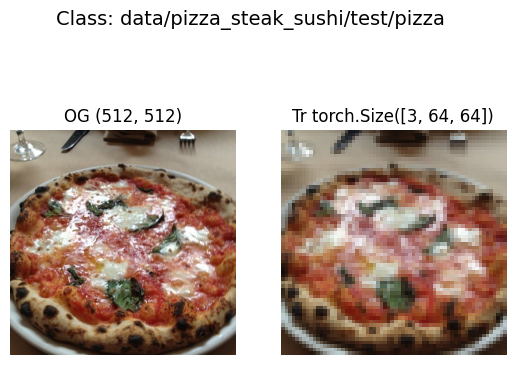

In [ ]:
display_random_img_transformation(image_path, train_transform_tvgg, n=1)

### Load image data using `ImageFolder`

In [ ]:
# Use ImageFolder to create dataset(s)
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
train_data = datasets.ImageFolder(
    root = train_dir,
    transform=train_transform_tvgg,
    target_transform=None
)
test_data = datasets.ImageFolder(
    root = test_dir,
    transform=test_transform_tvgg
)

In [ ]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the lengths of each dataset
len(train_data), len(test_data), type(train_data), type(test_data)

(225,
 75,
 torchvision.datasets.folder.ImageFolder,
 torchvision.datasets.folder.ImageFolder)

In [ ]:
# Turn train and test Datasets into DataLoaders
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size = BATCH_SIZE,
    num_workers= NUM_WORKERS,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bad88e91f90>,
 <torch.utils.data.dataloader.DataLoader at 0x7bad88e90290>)

In [ ]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader), len(train_data), len(test_data)

(8, 3, 225, 75)

In [ ]:
len(train_data) // BATCH_SIZE, len(test_data) // BATCH_SIZE, len(train_data) % BATCH_SIZE, len(test_data) % BATCH_SIZE

(7, 2, 1, 11)

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [ ]:
from torch import nn
class TinyVGG(nn.Module):
  def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(
            in_channels=input_shape,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.block2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units*16*16,
            out_features=output_shape
        )
    )

  def forward(self, x):
    x = self.block1(x)
    #print(f"Shape after block 1: {x.shape}")
    x = self.block2(x)
    #print(f"Shape after block 2: {x.shape}")
    return self.classifier(x)

In [ ]:
transformed_img = train_transform_tvgg(img)
transformed_img.shape

torch.Size([3, 64, 64])

In [ ]:
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)
model_0

TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [ ]:
model_0(transformed_img.unsqueeze(dim=0).to(device))

Shape after block 1: torch.Size([1, 10, 32, 32])
Shape after block 2: torch.Size([1, 10, 16, 16])


tensor([[-0.0075, -0.0719, -0.0172]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

## 4. Create training and testing functions for `model_0`.

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for index, (X, y) in enumerate(dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_logits = model(X)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_logits, y)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumulate accuracy metric across all batches
    train_loss += loss.item()
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    train_acc += ( (y_preds == y).sum().item() ) / len(y_preds)
  # Adjust metrics to get average loss and average accuracy per batch
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():

    # Loop through DataLoader batches
    for index, (X, y) in enumerate(dataloader):

      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_logits = model(X)

      # 2. Calculuate and accumulate loss
      loss = loss_fn(y_logits, y)

      # Calculate and accumulate accuracy
      test_loss += loss.item()
      y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
      test_acc += ( (y_preds==y).sum().item() ) / len(y_preds)

  # Adjust metrics to get average loss and accuracy per batch
  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  return test_loss, test_acc

In [ ]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": [],
             "epochs": []
            }

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)

    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
    results["epochs"].append(epoch)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.

In [ ]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

five_epochs_m0_results = train(
    model=model_0,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs= 5
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1050 | train_acc: 0.2617 | test_loss: 1.0972 | test_acc: 0.4640
Epoch: 2 | train_loss: 1.0869 | train_acc: 0.4453 | test_loss: 1.1079 | test_acc: 0.2708
Epoch: 3 | train_loss: 1.0689 | train_acc: 0.4258 | test_loss: 1.1250 | test_acc: 0.2708
Epoch: 4 | train_loss: 1.0552 | train_acc: 0.5156 | test_loss: 1.1284 | test_acc: 0.2917
Epoch: 5 | train_loss: 1.0066 | train_acc: 0.5508 | test_loss: 1.0670 | test_acc: 0.3627


In [ ]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGG(
    input_shape = 3,
    hidden_units = 10,
    output_shape=len(class_names)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

twenty_epochs_m1_results = train(
    model=model_1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs= 20
)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0846 | train_acc: 0.4258 | test_loss: 1.1622 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.1153 | train_acc: 0.2930 | test_loss: 1.1695 | test_acc: 0.1979
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.2891 | test_loss: 1.1342 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.0989 | train_acc: 0.2930 | test_loss: 1.1434 | test_acc: 0.1979
Epoch: 6 | train_loss: 1.0964 | train_acc: 0.3164 | test_loss: 1.1485 | test_acc: 0.2604
Epoch: 7 | train_loss: 1.1183 | train_acc: 0.3242 | test_loss: 1.1416 | test_acc: 0.3333
Epoch: 8 | train_loss: 1.1009 | train_acc: 0.3633 | test_loss: 1.1039 | test_acc: 0.2188
Epoch: 9 | train_loss: 1.0877 | train_acc: 0.4961 | test_loss: 1.0629 | test_acc: 0.5417
Epoch: 10 | train_loss: 1.0636 | train_acc: 0.4023 | test_loss: 1.0070 | test_acc: 0.5417
Epoch: 11 | train_loss: 1.0378 | train_acc: 0.4375 | test_loss: 0.9630 | test_acc: 0.6042
Epoch: 12 | train_l

In [ ]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_2 = TinyVGG(
    input_shape = 3,
    hidden_units = 10,
    output_shape=len(class_names)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),
                             lr=0.001)

fifty_epochs_m2_results = train(
    model=model_2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50
)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0846 | train_acc: 0.4258 | test_loss: 1.1622 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.1153 | train_acc: 0.2930 | test_loss: 1.1695 | test_acc: 0.1979
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.2891 | test_loss: 1.1342 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.0989 | train_acc: 0.2930 | test_loss: 1.1435 | test_acc: 0.1979
Epoch: 6 | train_loss: 1.0965 | train_acc: 0.3164 | test_loss: 1.1487 | test_acc: 0.2604
Epoch: 7 | train_loss: 1.1187 | train_acc: 0.3203 | test_loss: 1.1419 | test_acc: 0.3438
Epoch: 8 | train_loss: 1.1007 | train_acc: 0.3672 | test_loss: 1.1035 | test_acc: 0.2188
Epoch: 9 | train_loss: 1.0873 | train_acc: 0.4961 | test_loss: 1.0629 | test_acc: 0.5417
Epoch: 10 | train_loss: 1.0638 | train_acc: 0.4023 | test_loss: 1.0110 | test_acc: 0.5417
Epoch: 11 | train_loss: 1.0408 | train_acc: 0.4297 | test_loss: 0.9772 | test_acc: 0.6042
Epoch: 12 | train_l

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [ ]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_3 = TinyVGG(
    input_shape = 3,
    hidden_units=20,
    output_shape=len(class_names)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_3.parameters(),
    lr=0.001
)

train(
    model=model_3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=20
)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1074 | train_acc: 0.4180 | test_loss: 1.1063 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.1266 | train_acc: 0.3047 | test_loss: 1.1017 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0951 | train_acc: 0.3164 | test_loss: 1.0960 | test_acc: 0.4053
Epoch: 4 | train_loss: 1.0913 | train_acc: 0.4297 | test_loss: 1.0670 | test_acc: 0.5833
Epoch: 5 | train_loss: 1.0575 | train_acc: 0.5430 | test_loss: 1.0234 | test_acc: 0.5862
Epoch: 6 | train_loss: 0.9754 | train_acc: 0.5664 | test_loss: 1.1588 | test_acc: 0.3229
Epoch: 7 | train_loss: 1.0226 | train_acc: 0.4609 | test_loss: 0.9128 | test_acc: 0.5739
Epoch: 8 | train_loss: 0.9000 | train_acc: 0.6055 | test_loss: 1.0747 | test_acc: 0.3125
Epoch: 9 | train_loss: 0.8834 | train_acc: 0.4844 | test_loss: 1.0054 | test_acc: 0.3636
Epoch: 10 | train_loss: 0.9344 | train_acc: 0.5430 | test_loss: 0.9762 | test_acc: 0.4830
Epoch: 11 | train_loss: 0.8892 | train_acc: 0.5781 | test_loss: 1.0064 | test_acc: 0.3939
Epoch: 12 | train_l

{'train_loss': [1.1073544323444366,
  1.1265577226877213,
  1.0951344519853592,
  1.0913172960281372,
  1.0575259625911713,
  0.9754147678613663,
  1.0225654616951942,
  0.8999823182821274,
  0.8833792731165886,
  0.934440016746521,
  0.8892044275999069,
  0.9378108456730843,
  0.8711907491087914,
  0.9439001232385635,
  1.0394091233611107,
  0.7759782839566469,
  0.8380448669195175,
  0.79719602689147,
  0.7174884900450706,
  0.7150178086012602],
 'train_acc': [0.41796875,
  0.3046875,
  0.31640625,
  0.4296875,
  0.54296875,
  0.56640625,
  0.4609375,
  0.60546875,
  0.484375,
  0.54296875,
  0.578125,
  0.4765625,
  0.51171875,
  0.53515625,
  0.609375,
  0.66796875,
  0.55859375,
  0.66796875,
  0.6796875,
  0.71484375],
 'test_loss': [1.1062885522842407,
  1.101696769396464,
  1.0960066318511963,
  1.0669524272282918,
  1.0233661731084187,
  1.1588023106257122,
  0.9128144582112631,
  1.0747360189755757,
  1.0053876837094624,
  0.9761512080828348,
  1.0064469774564107,
  0.9927267

It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [ ]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...")
    zip_ref.extractall(image_path)

In [ ]:
twenty_pct_image_dir, twenty_pct_train_dir, twenty_pct_test_dir = create_data_path_and_download_zip_2(
    folder_name="pizza_steak_sushi_20_percent",
    file_name_w_extension = "pizza_steak_sushi_20_percent.zip",
    url="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip"
)

The path that will be created: data/pizza_steak_sushi_20_percent
'data/pizza_steak_sushi_20_percent' directory does not exist yet. Creating...
'data/pizza_steak_sushi_20_percent' path created.
Unzipping the data


In [ ]:
# See how many images we have
walk_through_dir(twenty_pct_image_dir)

There are 2 directories and 1 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.


Excellent, we now have double the training and testing images...

In [ ]:
# Create the train and test paths
train_data_20_percent_path = twenty_pct_image_dir / "train"
test_data_20_percent_path = twenty_pct_image_dir / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [ ]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.ToTensor()
])

# Create datasets
tpct_train_data = ImageFolder(
    root=train_data_20_percent_path,
    transform=train_transform_tvgg,
    target_transform=None
)
tpct_test_data = ImageFolder(
    root=test_data_20_percent_path,
    transform=test_transform_tvgg
)


# Create dataloaders
tpct_train_dataloader = DataLoader(
    dataset=tpct_train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)
tpct_test_dataloader = DataLoader(
    dataset=tpct_test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

In [ ]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Train a model with increased amount of data
import torch
from torch import nn

torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_4 = TinyVGG(
    input_shape = 3,
    hidden_units=15,
    output_shape=len(class_names)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_4.parameters(),
    lr=0.001
)

train(
    model=model_4,
    train_dataloader=tpct_train_dataloader,
    test_dataloader= tpct_test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=12
)

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1168 | train_acc: 0.2896 | test_loss: 1.0887 | test_acc: 0.3688
Epoch: 2 | train_loss: 1.0984 | train_acc: 0.3479 | test_loss: 1.0908 | test_acc: 0.3205
Epoch: 3 | train_loss: 1.0621 | train_acc: 0.4708 | test_loss: 1.0116 | test_acc: 0.5216
Epoch: 4 | train_loss: 0.9970 | train_acc: 0.6042 | test_loss: 0.9799 | test_acc: 0.5057
Epoch: 5 | train_loss: 0.9108 | train_acc: 0.5813 | test_loss: 0.9226 | test_acc: 0.5375
Epoch: 6 | train_loss: 0.8761 | train_acc: 0.6188 | test_loss: 0.9141 | test_acc: 0.6165
Epoch: 7 | train_loss: 0.8202 | train_acc: 0.6417 | test_loss: 0.9720 | test_acc: 0.5040
Epoch: 8 | train_loss: 0.8519 | train_acc: 0.6167 | test_loss: 0.8851 | test_acc: 0.5722
Epoch: 9 | train_loss: 0.7749 | train_acc: 0.6958 | test_loss: 0.8657 | test_acc: 0.6165
Epoch: 10 | train_loss: 0.7170 | train_acc: 0.6875 | test_loss: 0.8831 | test_acc: 0.6193
Epoch: 11 | train_loss: 0.7065 | train_acc: 0.6896 | test_loss: 0.8366 | test_acc: 0.6256
Epoch: 12 | train_l

{'train_loss': [1.11684357325236,
  1.0983609199523925,
  1.06208389600118,
  0.9969812234242758,
  0.9107920527458191,
  0.8760774691899618,
  0.8202219247817993,
  0.8519033670425415,
  0.7748662829399109,
  0.717016480366389,
  0.7065312057733536,
  0.6844782511393229],
 'train_acc': [0.28958333333333336,
  0.34791666666666665,
  0.4708333333333333,
  0.6041666666666666,
  0.58125,
  0.61875,
  0.6416666666666667,
  0.6166666666666667,
  0.6958333333333333,
  0.6875,
  0.6895833333333333,
  0.7291666666666666],
 'test_loss': [1.088710331916809,
  1.0907888889312745,
  1.01164767742157,
  0.9798715949058533,
  0.9225567817687989,
  0.9141433596611023,
  0.9720454156398773,
  0.8851102471351624,
  0.86572824716568,
  0.8831004500389099,
  0.8365775346755981,
  0.9001984179019928],
 'test_acc': [0.36875,
  0.32045454545454544,
  0.5215909090909091,
  0.5056818181818181,
  0.5375,
  0.6164772727272727,
  0.5039772727272728,
  0.5721590909090909,
  0.6164772727272727,
  0.619318181818181

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction.
* Does the model you trained in exercise 7 get it right?
* If not, what do you think you could do to improve it?

In [ ]:
import requests

custom_img_path = data_path / "some_image.jpeg"

if not custom_img_path.is_file():
  with open(custom_img_path, "wb") as f:
    request = requests.get("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQGpYR-HLnSzflqC69CBNn3luQjavbCLd_01g&s")
    print(f"Downloading custom image {custom_img_path}")
    f.write(request.content)
else:
  print(f"{custom_img_path} already exists")


<class 'torch.Tensor'>


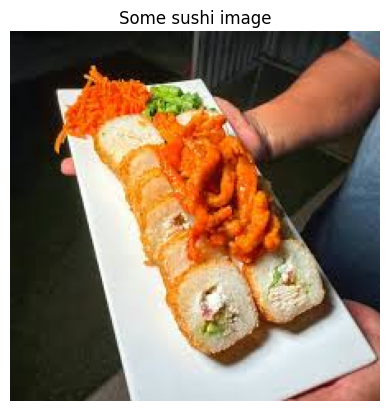

In [ ]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(
    path=custom_img_path
)
plt.imshow(custom_image_uint8.permute(1, 2, 0))
plt.axis(False)
plt.title("Some sushi image")
print(type(custom_image_uint8))

In [ ]:
device

'cuda'

In [ ]:
custom_img = custom_image_uint8.to(torch.float32)
transform_inf = transforms.Compose([
    transforms.Resize(size=(64, 64))
])
custom_img = transform_inf(custom_img)
custom_img /= 255.
print(custom_img.dtype, custom_img.shape)

torch.float32 torch.Size([3, 64, 64])


In [ ]:
custom_img_permute = custom_img.permute(1, 2, 0)
custom_img_permute.shape

torch.Size([64, 64, 3])

Pred probs: tensor([0.2219, 0.0158, 0.7623])


Text(0.5, 1.0, 'P: sushi | Prob: 0.762')

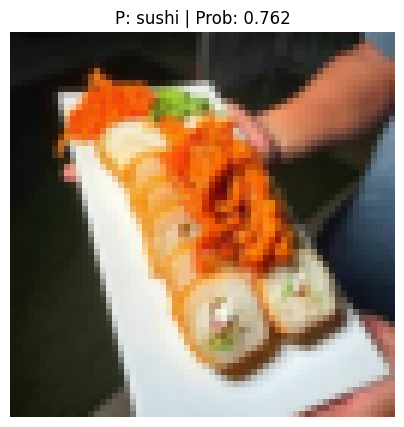

In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(custom_img.unsqueeze(dim=0))
  y_pred_probs = torch.softmax(y_logits, dim=1)
  y_preds = torch.argmax(y_pred_probs, dim=1)
  print(f"Pred probs: {y_pred_probs.squeeze()}")

plt.figure(figsize=(5, 5))
plt.imshow(custom_img_permute)
plt.axis(False)
plt.title(f"P: {class_names[y_preds]} | Prob: {y_pred_probs.squeeze()[y_preds].item():.3f}")

It got it right with quite some confidence, which may mean various things, I think

Either the model performs better on sushi due to having more examples of it, or this image may be in the training set.

What makes me suspicious is that the overall performance seen in the training process indicates this model is a bit flawed.

# ChatGPT metadata cleaning

In [ ]:
import nbformat

notebook_path = "/content/drive/MyDrive/Colab Notebooks/04_pytorch_custom_datasets_exercises.ipynb"

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']
    print("Removed 'widgets' metadata.")
else:
    print("No 'widgets' metadata found.")

with open(notebook_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)
    print("Notebook cleaned and saved back to Drive.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/04_pytorch_custom_datasets_exercises.ipynb'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')